<a href="https://colab.research.google.com/github/Sravanthiedimpalli/Data-Driven-Insights-from-Chipotle-Sales/blob/main/Chipotle_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data-Driven-Insights-from-Chipotle-Sales**

##**Step 1. Import the necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##**step 2. Import the dataset from this**
https://drive.google.com/file/d/1Drj8dq3zwM527mUVESiWBTtVKjrsKy cM/view?usp=sharing

## **step 3. Assign it to a variable called chipo.**

In [ ]:
chipo = pd.read_csv("/content/chipotle.csv",sep="\t")
chipo

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


#**Data Cleaning**

**1.Head**

In [ ]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


**2.Tail**

In [ ]:
chipo.tail()

,order_id,quantity,item_name,choice_description,item_price
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",8.75
4621,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",8.75


3. **Info**

In [ ]:
chipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            4622 non-null   int64 
 1   quantity            4622 non-null   int64 
 2   item_name           4622 non-null   object
 3   choice_description  3376 non-null   object
 4   item_price          4622 non-null   object
dtypes: int64(2), object(3)
memory usage: 180.7+ KB


**4.Describe**

In [ ]:
chipo.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


**5.Null**

In [ ]:
chipo.isnull().sum()

,0
order_id,0
quantity,0
item_name,0
choice_description,1246
item_price,0


**6. Duplicate**

In [ ]:
chipo[chipo.duplicated()]

,order_id,quantity,item_name,choice_description,item_price
238,103,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Rice, Black Beans...",11.75
248,108,1,Canned Soda,[Mountain Dew],1.09
297,129,1,Steak Burrito,"[Tomatillo Green Chili Salsa, [Rice, Cheese, G...",11.75
381,165,1,Canned Soft Drink,[Coke],1.25
484,205,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",8.75
567,233,1,Canned Soft Drink,[Diet Coke],1.25
617,254,1,Chips,NaN,2.15
684,282,1,Canned Soft Drink,[Coke],1.25
773,319,1,Chicken Bowl,"[Tomatillo-Green Chili Salsa (Medium), Black B...",8.49
908,376,1,Steak Burrito,"[Roasted Chili Corn Salsa (Medium), [Rice, Faj...",8.99


##**step 4. See the first 10 entries**


In [ ]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


##**step 5. What is the number of observations in the dataset**


In [ ]:
len(chipo)

4622

 # **step 6.What is the number of columns in the dataset**


In [ ]:
len(chipo.columns)

5

# **Step 7. Print the name of all the columns.**


In [ ]:
chipo.dtypes


,0
order_id,int64
quantity,int64
item_name,object
choice_description,object
item_price,float64
total_price,float64


# **Step 8. How is the dataset indexed?**

In [ ]:
chipo.index


RangeIndex(start=0, stop=4622, step=1)

# **Step 9. Which was the most-ordered item?**


In [ ]:
item_totals = chipo.groupby('item_name')['quantity'].sum()
sorted_items = item_totals.sort_values(ascending=False)
most_ordered_item = sorted_items.idxmax()
most_ordered_quantity = sorted_items.max()
print(f"The most ordered item is: {most_ordered_item} with total quantity {most_ordered_quantity}")



The most ordered item is: Chicken Bowl with total quantity 761


# **Step 10. For the most-ordered item, how many items were ordered?**

In [ ]:
item_totals = chipo.groupby('item_name')['quantity'].sum()
most_ordered_quantity = item_totals.max()
print(f'For the most-ordered item, the total quantity ordered was: {most_ordered_quantity}')

For the most-ordered item, the total quantity ordered was: 761


# **Step 11. Most ordered item in choice_description**

In [ ]:
choice_totals = chipo.groupby('choice_description')['quantity'].sum()
sorted_choices = choice_totals.sort_values(ascending=False)
most_ordered_choice = sorted_choices.idxmax()
most_ordered_quantity = sorted_choices.max()
print(f"The most ordered choice description is: {most_ordered_choice} with quantity {most_ordered_quantity}")

The most ordered choice description is: [Diet Coke] with quantity 159


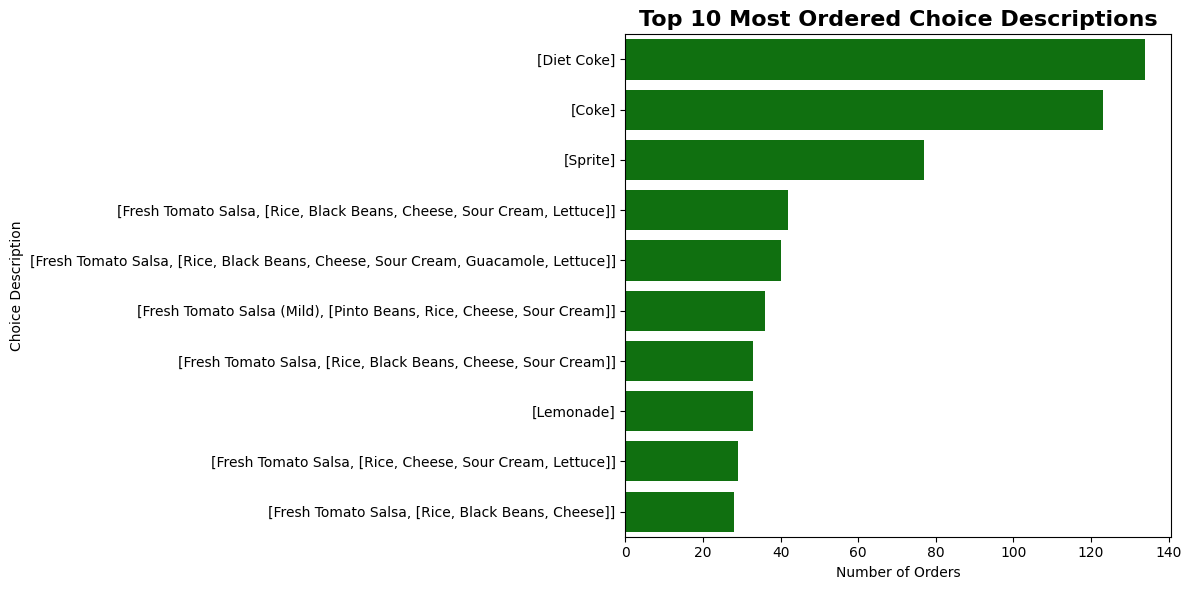

In [ ]:
choice_counts = chipo['choice_description'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=choice_counts.values, y=choice_counts.index, color='green')
plt.title("Top 10 Most Ordered Choice Descriptions", fontsize=16, weight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("Choice Description")
plt.tight_layout()
plt.show()


# **Step 12. Total items ordered**

In [ ]:
total_items = chipo['quantity'].sum()
print("Total items ordered:", total_items)





Total items ordered: 4972


# **Step 13. Turn item price into a float**


In [ ]:
print("Current item_price type:", chipo['item_price'].dtype)
chipo['item_price'].head()

Current item_price type: float64


,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98


# **13.b.Apply lambda to convert**

In [ ]:
chipo['item_price'] = chipo['item_price'].astype(str) \
    .str.replace('$', '', regex=False) \
    .str.replace(',', '', regex=False) \
    .astype(float)
chipo['item_price'].head()



,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98


# **13.c.Check again**

In [ ]:
chipo['item_price'].dtype


dtype('float64')

# **Step 14. Revenue for the dataset period**

In [ ]:
revenue = (chipo['quantity'] * chipo['item_price']).sum()
revenue


np.float64(39237.02)

# **Step 15. Number of orders made**

In [ ]:
total_orders = chipo['order_id'].nunique()
print("Total number of orders:", total_orders)



Total number of orders: 1834


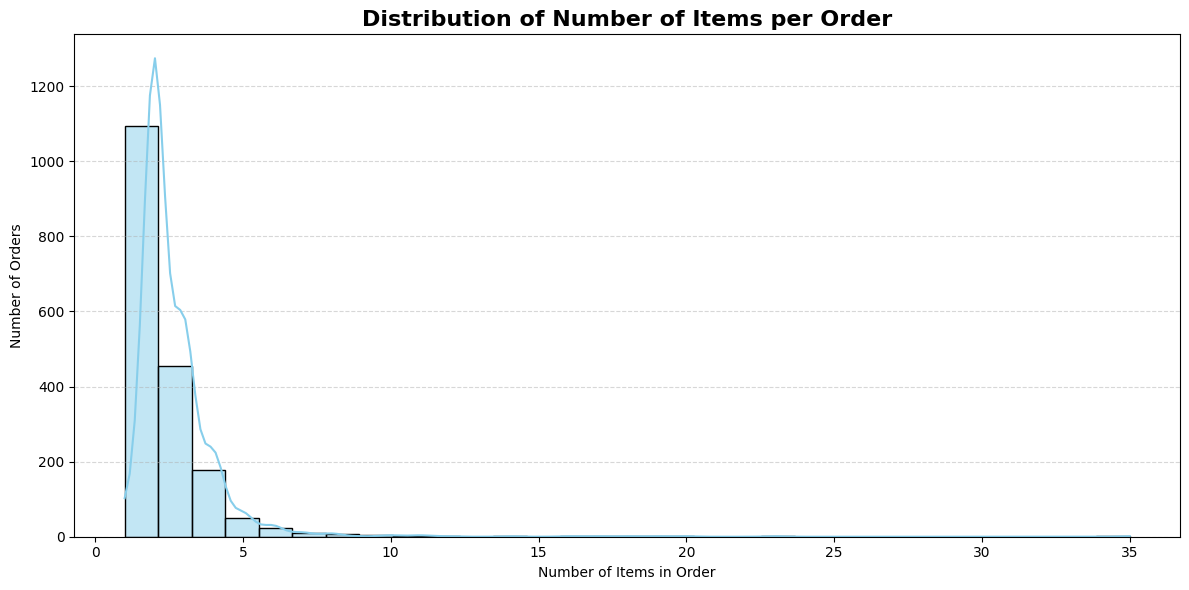

In [ ]:

order_size = chipo.groupby('order_id')['quantity'].sum()
plt.figure(figsize=(12,6))
sns.histplot(order_size, bins=30, kde=True, color='skyblue')
plt.title("Distribution of Number of Items per Order", fontsize=16, weight='bold')
plt.xlabel("Number of Items in Order")
plt.ylabel("Number of Orders")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# **16. Average revenue per order**

In [ ]:
revenue / chipo['order_id'].nunique()


np.float64(21.39423118865867)

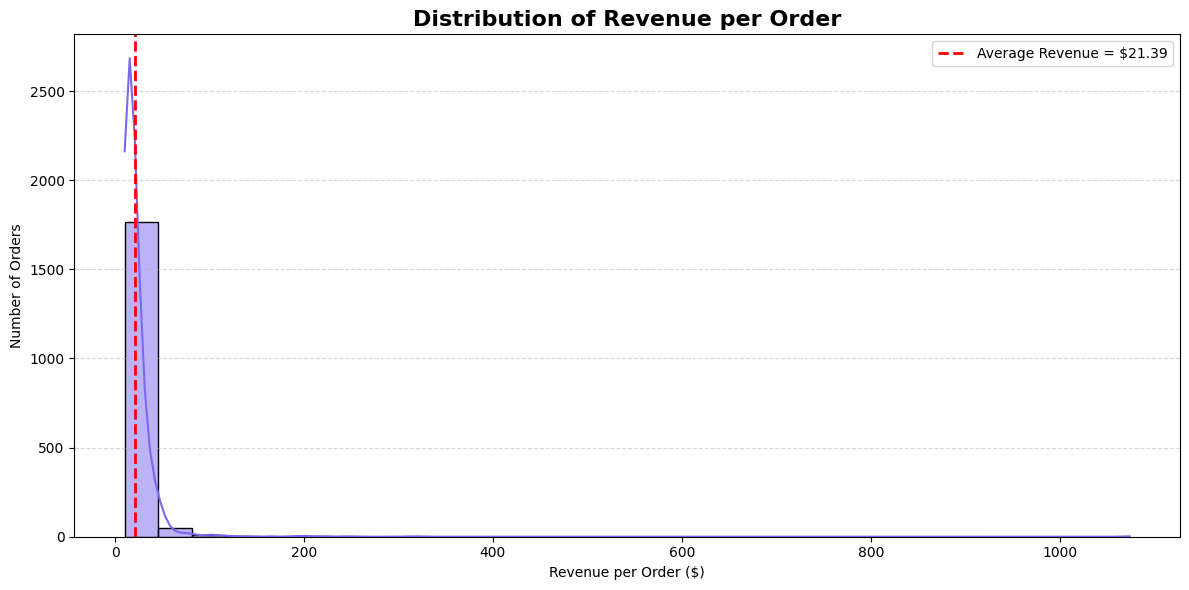

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(order_revenue, bins=30, kde=True, color='mediumslateblue')
plt.axvline(average_revenue, color='red', linestyle='--', linewidth=2, label=f'Average Revenue = ${average_revenue:.2f}')
plt.title("Distribution of Revenue per Order", fontsize=16, weight='bold')
plt.xlabel("Revenue per Order ($)")
plt.ylabel("Number of Orders")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




# **Step 17. Number of different items sold**

In [ ]:
num_items_sold = chipo['item_name'].nunique()
print("Number of different items sold:", num_items_sold)


Number of different items sold: 50


# **Data Visualization**

**Create a bar chart of top 10 most-ordered items**

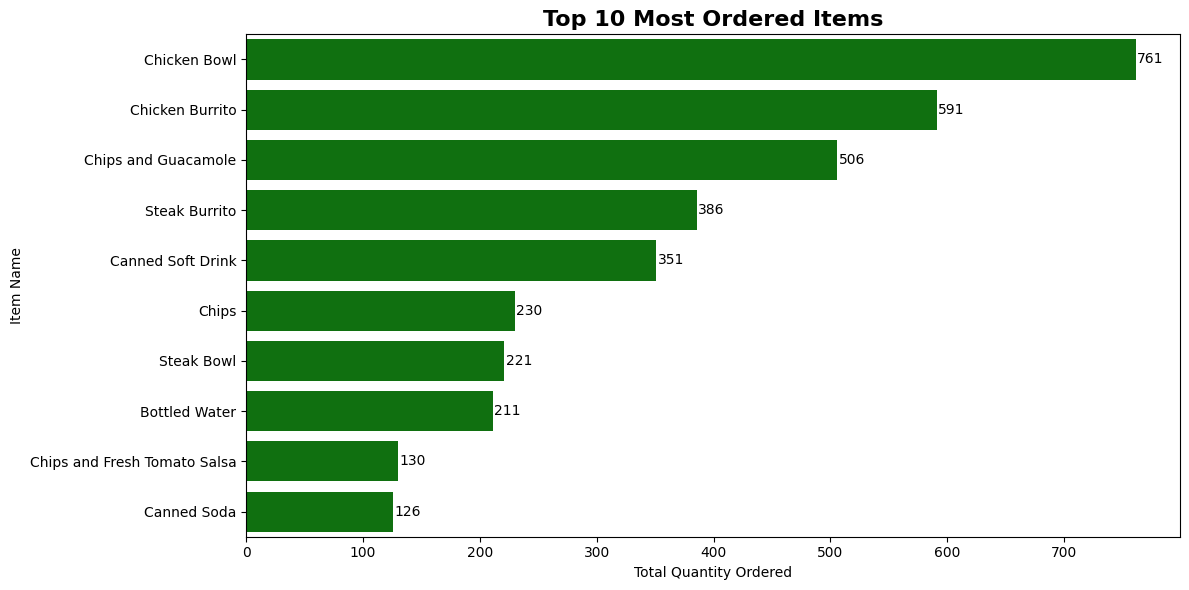

In [ ]:
item_quantity = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=item_quantity.values, y=item_quantity.index, color='green')
plt.title("Top 10 Most Ordered Items", fontsize=16, weight='bold')
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Item Name")
for i, v in enumerate(item_quantity.values):
    plt.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()


**Create a pie chart showing the proportion of different choice_description categories.**

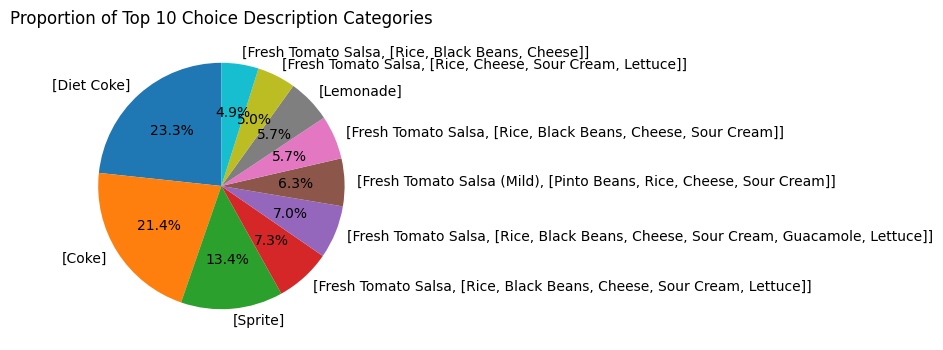

In [ ]:
choice_counts = chipo['choice_description'].value_counts().head(10)  # top 10 for clarity
plt.figure(figsize=(8,4))
plt.pie(choice_counts.values, labels=choice_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Proportion of Top 10 Choice Description Categories")
plt.show()

**Identify high-revenue generating items.**


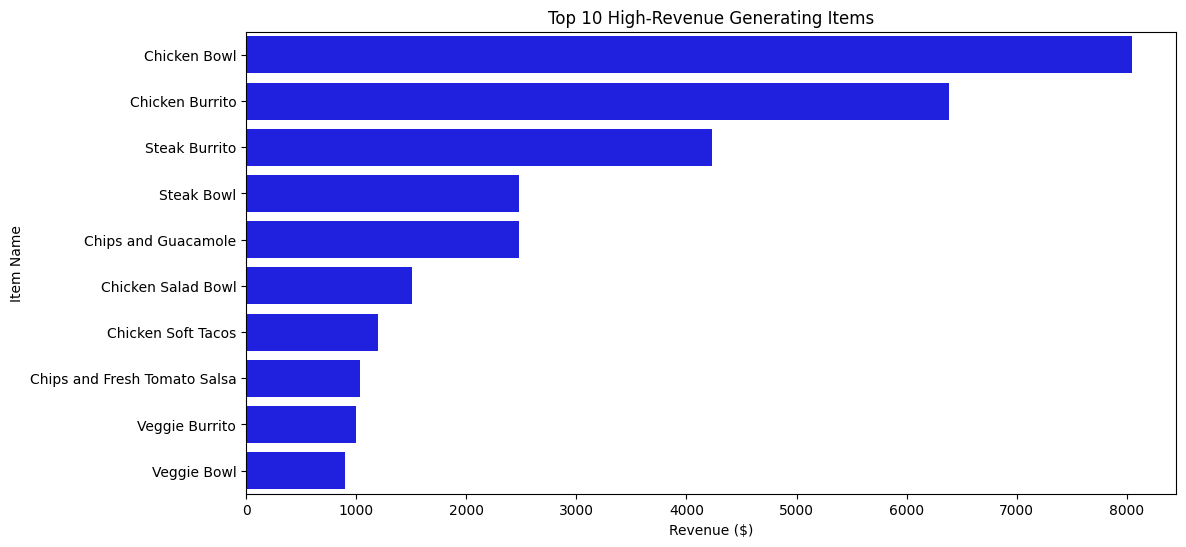

In [ ]:
chipo['revenue'] = chipo['quantity'] * chipo['item_price']
item_revenue = chipo.groupby('item_name')['revenue'].sum().sort_values(ascending=False)
top_items = item_revenue.head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values, y=top_items.index, color='blue')
plt.xlabel('Revenue ($)')
plt.ylabel('Item Name')
plt.title('Top 10 High-Revenue Generating Items')
plt.show()

**Suggest business insights from your analysis**

1. A few items, such as “Chicken Bowl” and “Steak Burrito,” generate most of the revenue, so focusing marketing, promotions, and inventory on these can boost profits.

2. Popular choice customizations like “Extra Cheese” or “Guacamole” increase order frequency, suggesting that bundling add-ons can raise average order value.

3. Low-priced, high-quantity items and high-priced, less frequent items reveal opportunities to optimize pricing and cross-sell, balancing volume and profit margin.